In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from utils.cub_config import Config
import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from tqdm import tqdm
from PIL import Image
from torchvision import models, transforms
import cv2 
from skimage.transform import resize
import matplotlib.pyplot as plt
import os
from utils.cub_config import Config
from pytorch_grad_cam import ScoreCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

model_path = Config.MODEL
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, 200)
model.load_state_dict(torch.load(model_path, map_location=device, weights_only=True))
model.eval()

Usando dispositivo: cuda


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [4]:
transform = transforms.Compose([
    transforms.Resize((448, 448)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
image_path = "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0015_796858.jpg"
img = Image.open(image_path).convert('RGB')
input_tensor = transform(img).unsqueeze(0)

target_layer = model.layer4[-1]
cam = ScoreCAM(model=model, target_layers=[target_layer])
targets = [ClassifierOutputTarget(26)]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
grayscale_cam = grayscale_cam / grayscale_cam.max()


rgb_img = np.array(img.resize((448, 448))) / 255.0
vis = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.imshow(vis)
plt.axis('off')
plt.show()

 90%|████████▉ | 115/128 [09:04<01:01,  4.74s/it]


## AVALIAÇÃO

In [ ]:
from cub_eval import deletion_test

In [ ]:
image_path = "../../data/CUB-200-2011/images/test/027.Shiny_Cowbird/Shiny_Cowbird_0015_796858.jpg"
img = Image.open(image_path).convert('RGB')
input_tensor = transform(img).unsqueeze(0)

preds = model(input_tensor)
pred_class = torch.argmax(preds, dim=1).item()
print(f"Predicted class: {pred_class}")

# target_layer = model.layer4[-1]
# cam = ScoreCAM(model=model, target_layers=[target_layer])
# targets = [ClassifierOutputTarget(pred_class)]
# grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]
# grayscale_cam = grayscale_cam / grayscale_cam.max()


confidences, predictions = deletion_test(model, input_tensor, grayscale_cam, pred_class, max_steps=100)

Predicted class: 26


Text(0.5, 1.0, 'Deletion Test')

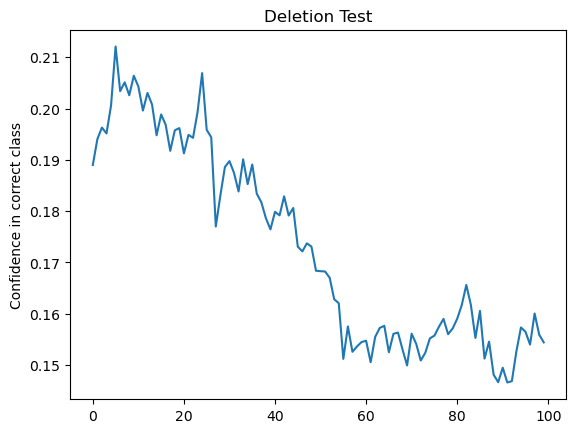

In [ ]:
## plot confidences

plt.plot(confidences)
plt.ylabel('Confidence in correct class')
plt.title('Deletion Test')

Text(0.5, 1.0, 'Deletion Test')

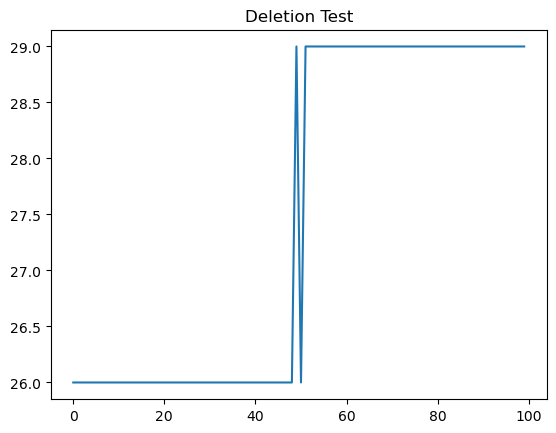

In [ ]:
plt.plot(predictions)
plt.title('Deletion Test')

## ROBUSTNESS

In [ ]:
from cub_eval import robustness_test
robustness_score = robustness_test(model, 'ScoreCAM', input_tensor, cam, targets)